# Hyperparameter Tuning with Optuna & MLflow

Tuning hyperparameters is a critical step in the CD4ML lifecycle to prevent overfitting and optimize prediction accuracy. In this notebook, we automate the hyperparameter sweep over the regularization strength $\alpha$ of our closed-form `RidgeDemandRegressor` using **Optuna**.

### Why Optuna?
- **Efficient Search**: Instead of grid search, Optuna uses a Tree-structured Parzen Estimator (TPE) sampler to suggest values, focusing on promising regions in log-space.
- **Integration**: We run 25 trials, logging each parameter selection and the resulting validation metrics to **MLflow** as a nested run inside a parent `hyperparameter_tuning` run to preserve experiment history.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
from nyc_taxi_demand_forecasting.configuration import ProjectConfigLoader
from nyc_taxi_demand_forecasting.models.tuning import DemandModelTuner

# Load project configuration
config_path = Path("../configs/project.yaml")
config = ProjectConfigLoader().load(config_path)

# Execute Optuna study search
tuner = DemandModelTuner()
result = tuner.select_best(
    dataset_path=config.features.training_dataset_path,
    target_column=config.training.target_column,
    test_size=config.training.test_size,
    feast_config=config.feast,
    mlflow_config=config.mlflow,
)

print("Tuning completed successfully!")
print(f"Optimal Alpha regularization: {result.alpha:.4f}")
print(
    f"Best Validation Mean Absolute Error (MAE): {result.validation_mae:.4f}"
)

/home/gabriel-menezes/Documents/repos/mlops/.venv/lib/python3.11/site-packages/ibis/backends/duckdb/__init__.py:332: DeprecationWarning: fetch_arrow_table() is deprecated, use to_arrow_table() instead.
  meta = result.fetch_arrow_table()


Tuning completed successfully!
Optimal Alpha regularization: 9917.0641
Best Validation Mean Absolute Error (MAE): 10.9974


## Retrieve and Plot Metrics from MLflow
We can query the MLflow Tracking Server using `mlflow.search_runs` to visualize the performance across our hyperparameter space.

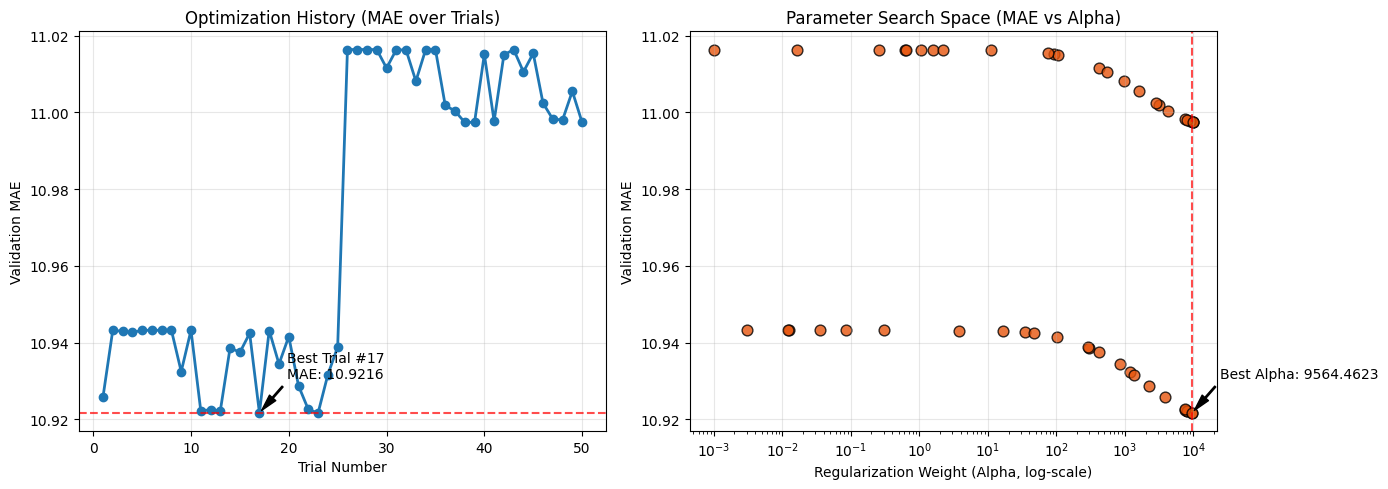

In [2]:
# Retrieve all trial runs under the active experiment
experiment = mlflow.get_experiment_by_name("nyc_taxi_demand_forecasting")
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName LIKE 'tune_ridge_trial_%'",
)

# Extract parameters and metrics
runs["alpha"] = runs["params.alpha"].astype(float)
runs["mae"] = runs["metrics.mae"].astype(float)
runs = runs.sort_values("start_time").reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization History
ax1.plot(
    runs.index + 1,
    runs["mae"],
    marker="o",
    color="#1f77b4",
    linewidth=2,
)
best_idx = runs["mae"].idxmin()
best_mae = runs.loc[best_idx, "mae"]
best_alpha = runs.loc[best_idx, "alpha"]

ax1.axhline(best_mae, color="red", linestyle="--", alpha=0.7)
ax1.annotate(
    f"Best Trial #{best_idx + 1}\nMAE: {best_mae:.4f}",
    xy=(best_idx + 1, best_mae),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops=dict(facecolor="black", shrink=0.08, width=1, headwidth=6),
    fontsize=10,
)
ax1.set_title("Optimization History (MAE over Trials)", fontsize=12)
ax1.set_xlabel("Trial Number", fontsize=10)
ax1.set_ylabel("Validation MAE", fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Parameter Search Space
ax2.scatter(
    runs["alpha"],
    runs["mae"],
    color="#e6550d",
    s=60,
    alpha=0.8,
    edgecolors="k",
)
ax2.set_xscale("log")
ax2.axvline(best_alpha, color="red", linestyle="--", alpha=0.7)
ax2.annotate(
    f"Best Alpha: {best_alpha:.4f}",
    xy=(best_alpha, best_mae),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops=dict(facecolor="black", shrink=0.08, width=1, headwidth=6),
    fontsize=10,
)
ax2.set_title("Parameter Search Space (MAE vs Alpha)", fontsize=12)
ax2.set_xlabel("Regularization Weight (Alpha, log-scale)", fontsize=10)
ax2.set_ylabel("Validation MAE", fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()